# Denoising Diffusion Implicit Models (DDIM) Inference Experiments

This notebook implements the inference experiments for DDIM as specified in `ddim.md` to demonstrate:
1. **Speed vs. Quality**: Accelerated sampling of DDIM compared to DDPM.
2. **Determinism**: The deterministic nature of DDIM sampling ($\eta = 0.0$) versus stochastic DDPM.
3. **Semantic Interpolation**: Blending latent noise vectors with Spherical Linear Interpolation (SLERP) and reconstructing using DDIM.

In [1]:
import os
# Set MPS high watermark ratio to 0.0 to disable strict upper limits on GPU memory allocation
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import time
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from configs.config import DiffusionConfig
from models.unet import UNet
from models.diffusion import Diffusion
from utils.tools import show_images

In [2]:
def slerp(v0: torch.Tensor, v1: torch.Tensor, t: float) -> torch.Tensor:
    """Spherical linear interpolation between two normalized vectors."""
    v0_norm = v0 / torch.norm(v0, dim=-1, keepdim=True)
    v1_norm = v1 / torch.norm(v1, dim=-1, keepdim=True)
    dot = torch.sum(v0_norm * v1_norm, dim=-1, keepdim=True)
    omega = torch.acos(torch.clamp(dot, -1.0, 1.0))
    sin_omega = torch.sin(omega)
    
    # Fallback to linear interpolation (lerp) if vectors are nearly parallel
    res = torch.where(
        sin_omega < 1e-5,
        (1.0 - t) * v0 + t * v1,
        (torch.sin((1.0 - t) * omega) / sin_omega) * v0 + (torch.sin(t * omega) / sin_omega) * v1
    )
    return res

In [3]:
device = torch.device(DiffusionConfig.DEVICE)
print(f"Using device: {device}")

# Clear MPS cache to free up memory before instantiating models
if device.type == "mps":
    torch.mps.empty_cache()
    print("Cleared MPS cache memory.")

model = UNet(
    in_channels=DiffusionConfig.CHANNELS,
    out_channels=DiffusionConfig.CHANNELS,
    base_channels=96,
    num_classes=DiffusionConfig.NUM_CLASSES
).to(device)

diffusion = Diffusion(
    timesteps=DiffusionConfig.TIMESTEPS,
    beta_start=DiffusionConfig.BETA_START,
    beta_end=DiffusionConfig.BETA_END,
    schedule_type="cosine"
).to(device)

# Load the trained checkpoint and map to the active device
checkpoint = torch.load("checkpoints/ddpm_mnist_epoch_30.pth", map_location=device)
model.load_state_dict(checkpoint['ema_shadow'])
print("Checkpoint EMA shadow weights successfully loaded.")

Using device: mps
Cleared MPS cache memory.
Checkpoint EMA shadow weights successfully loaded.


## Experiment 1: Speed vs. Quality

We generate digit images using:
1. Standard DDPM sampling (1000 steps)
2. DDIM sampling (50 steps, $\eta=0.0$)
3. DDIM sampling (20 steps, $\eta=0.0$)

We compare their execution speed and visual quality using the exact same starting noise.

In [4]:
torch.manual_seed(42)
num_samples = 10
c_test = torch.arange(10, device=device)

# Initialize starting noise
seed_noise = torch.randn((num_samples, DiffusionConfig.CHANNELS, DiffusionConfig.IMG_SIZE, DiffusionConfig.IMG_SIZE), device=device)

# 1. Measure standard DDPM (1000 steps)
t0 = time.perf_counter()
x_ddpm = seed_noise.clone()
with torch.no_grad():
    for t in reversed(range(diffusion.timesteps)):
        t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=device)
        x_ddpm = diffusion.p_sample(model, x_ddpm, t_tensor, c_test, cfg_scale=1.5)
t_ddpm = time.perf_counter() - t0
print(f"DDPM (1000 steps) completed in: {t_ddpm:.3f}s")

# 2. Measure DDIM (50 steps)
t0 = time.perf_counter()
x_ddim_50 = diffusion.ddim_sample(
    model=model,
    num_samples=num_samples,
    channels=DiffusionConfig.CHANNELS,
    img_size=DiffusionConfig.IMG_SIZE,
    device=device,
    c=c_test,
    steps=50,
    eta=0.0,
    cfg_scale=1.5,
    x_init=seed_noise
)
t_ddim_50 = time.perf_counter() - t0
print(f"DDIM (50 steps) completed in: {t_ddim_50:.3f}s (Speedup: {t_ddpm/t_ddim_50:.1f}x)")

# 3. Measure DDIM (20 steps)
t0 = time.perf_counter()
x_ddim_20 = diffusion.ddim_sample(
    model=model,
    num_samples=num_samples,
    channels=DiffusionConfig.CHANNELS,
    img_size=DiffusionConfig.IMG_SIZE,
    device=device,
    c=c_test,
    steps=20,
    eta=0.0,
    cfg_scale=1.5,
    x_init=seed_noise
)
t_ddim_20 = time.perf_counter() - t0
print(f"DDIM (20 steps) completed in: {t_ddim_20:.3f}s (Speedup: {t_ddpm/t_ddim_20:.1f}x)")

DDPM (1000 steps) completed in: 71.590s
DDIM (50 steps) completed in: 3.299s (Speedup: 21.7x)
DDIM (20 steps) completed in: 1.320s (Speedup: 54.2x)


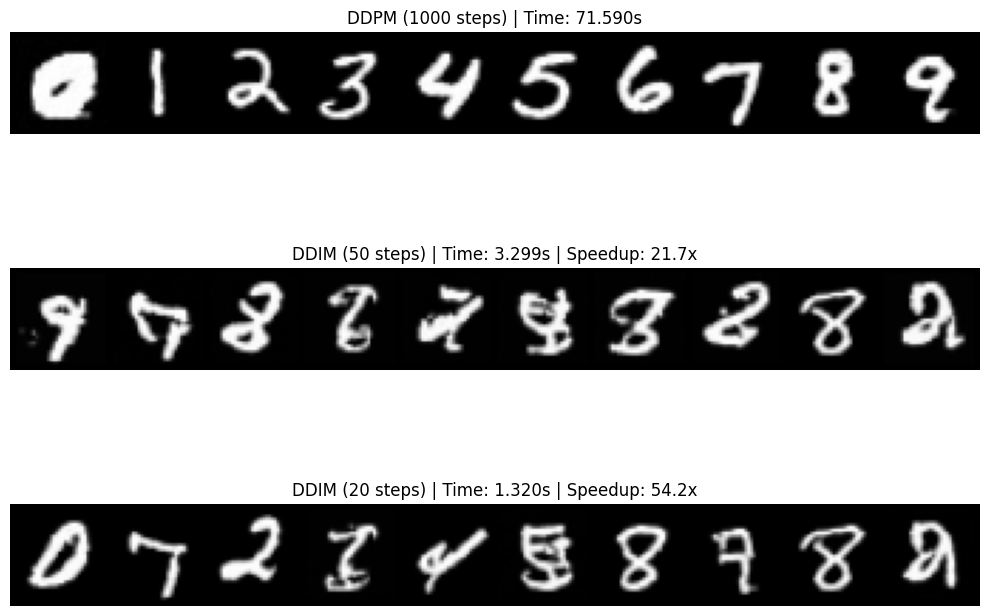

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

def plot_to_ax(ax, images, title):
    grid_img = torchvision.utils.make_grid(images, nrow=num_samples, normalize=True, value_range=(-1, 1))
    grid_np = grid_img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(grid_np)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plot_to_ax(axes[0], x_ddpm, f"DDPM (1000 steps) | Time: {t_ddpm:.3f}s")
plot_to_ax(axes[1], x_ddim_50, f"DDIM (50 steps) | Time: {t_ddim_50:.3f}s | Speedup: {t_ddpm/t_ddim_50:.1f}x")
plot_to_ax(axes[2], x_ddim_20, f"DDIM (20 steps) | Time: {t_ddim_20:.3f}s | Speedup: {t_ddpm/t_ddim_20:.1f}x")

plt.tight_layout()
plt.savefig("outputs/ddim_speed_vs_quality.png", bbox_inches='tight')
plt.show()

## Experiment 2: Determinism vs. Stochasticity

We run sampling 3 times from the same fixed latent vector using:
1. Standard DDPM (stochastic)
2. DDIM with $\eta=0.0$ (deterministic)

This demonstrates the deterministic trajectory of DDIM.

In [6]:
# Fixed target digit: 5
c_single = torch.full((1,), 5, dtype=torch.long, device=device)
fixed_noise = torch.randn((1, DiffusionConfig.CHANNELS, DiffusionConfig.IMG_SIZE, DiffusionConfig.IMG_SIZE), device=device)

# Repeat sampling 3 times with DDPM (stochastic)
ddpm_outputs = []
with torch.no_grad():
    for i in range(3):
        x_noise = fixed_noise.clone()
        for t in reversed(range(diffusion.timesteps)):
            t_tensor = torch.full((1,), t, dtype=torch.long, device=device)
            x_noise = diffusion.p_sample(model, x_noise, t_tensor, c_single, cfg_scale=1.5)
        ddpm_outputs.append(x_noise)

# Repeat sampling 3 times with DDIM (deterministic, eta=0.0)
ddim_outputs = []
for i in range(3):
    x_ddim = diffusion.ddim_sample(
        model=model,
        num_samples=1,
        channels=DiffusionConfig.CHANNELS,
        img_size=DiffusionConfig.IMG_SIZE,
        device=device,
        c=c_single,
        steps=50,
        eta=0.0,
        cfg_scale=1.5,
        x_init=fixed_noise
)
    ddim_outputs.append(x_ddim)

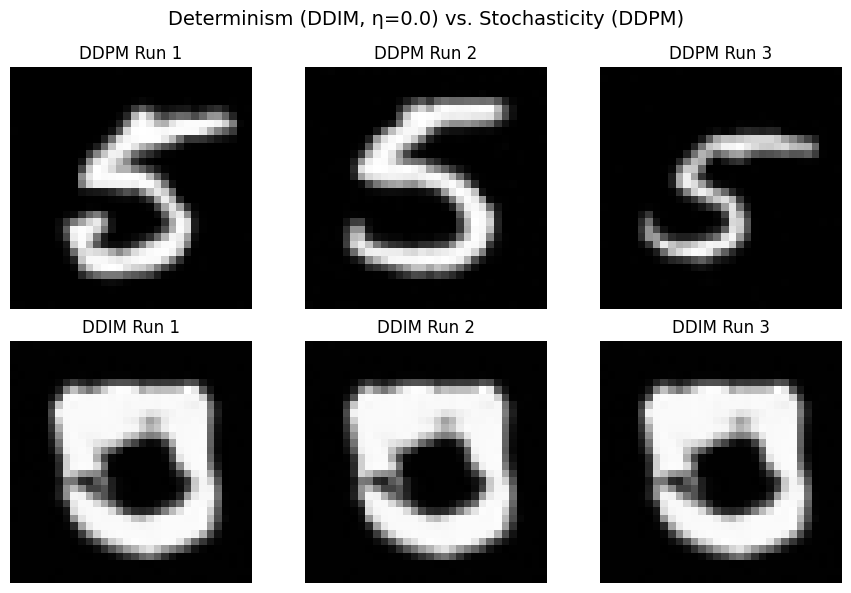

Max absolute difference between DDIM Run 1 & 2: 0.0
Max absolute difference between DDIM Run 2 & 3: 0.0


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for idx in range(3):
    # DDPM plots (stochastic - show slight variations)
    img_ddpm = torchvision.utils.make_grid(ddpm_outputs[idx], normalize=True, value_range=(-1, 1)).cpu().numpy().transpose((1, 2, 0))
    axes[0, idx].imshow(img_ddpm)
    axes[0, idx].set_title(f"DDPM Run {idx+1}")
    axes[0, idx].axis('off')
    
    # DDIM plots (deterministic - show identical pixels)
    img_ddim = torchvision.utils.make_grid(ddim_outputs[idx], normalize=True, value_range=(-1, 1)).cpu().numpy().transpose((1, 2, 0))
    axes[1, idx].imshow(img_ddim)
    axes[1, idx].set_title(f"DDIM Run {idx+1}")
    axes[1, idx].axis('off')

plt.suptitle("Determinism (DDIM, η=0.0) vs. Stochasticity (DDPM)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("outputs/ddim_determinism.png", bbox_inches='tight')
plt.show()

# Verify mathematical pixel-perfect identity for DDIM
diff_1_2 = torch.max(torch.abs(ddim_outputs[0] - ddim_outputs[1])).item()
diff_2_3 = torch.max(torch.abs(ddim_outputs[1] - ddim_outputs[2])).item()
print(f"Max absolute difference between DDIM Run 1 & 2: {diff_1_2}")
print(f"Max absolute difference between DDIM Run 2 & 3: {diff_2_3}")

## Experiment 3: Semantic Interpolation (Slerp)

We interpolate between two distinct high-dimensional Gaussian noise vectors $x_T^{(A)}$ and $x_T^{(B)}$ using Spherical Linear Interpolation (SLERP) and generate the intermediate morphed images using DDIM ($\eta=0.0$).

In [8]:
# Generate two distinct noise vectors
torch.manual_seed(100)
latent_a = torch.randn((1, DiffusionConfig.CHANNELS * DiffusionConfig.IMG_SIZE * DiffusionConfig.IMG_SIZE), device=device)
latent_b = torch.randn((1, DiffusionConfig.CHANNELS * DiffusionConfig.IMG_SIZE * DiffusionConfig.IMG_SIZE), device=device)

# Interpolate using slerp
alphas = np.linspace(0.0, 1.0, 10)
interpolated_latents = []
for alpha in alphas:
    interpolated_latent = slerp(latent_a, latent_b, alpha)
    interpolated_latent = interpolated_latent.view(1, DiffusionConfig.CHANNELS, DiffusionConfig.IMG_SIZE, DiffusionConfig.IMG_SIZE)
    interpolated_latents.append(interpolated_latent)

# Denoise all 10 latents using DDIM (steps=50, eta=0.0)
# We transition the conditional class label from 3 to 8 alongside the noise blending
morphed_images = []
for idx, latent in enumerate(interpolated_latents):
    alpha = alphas[idx]
    label = 3 if alpha < 0.5 else 8
    c_step = torch.full((1,), label, dtype=torch.long, device=device)
    
    img = diffusion.ddim_sample(
        model=model,
        num_samples=1,
        channels=DiffusionConfig.CHANNELS,
        img_size=DiffusionConfig.IMG_SIZE,
        device=device,
        c=c_step,
        steps=50,
        eta=0.0,
        cfg_scale=1.5,
        x_init=latent
    )
    morphed_images.append(img)

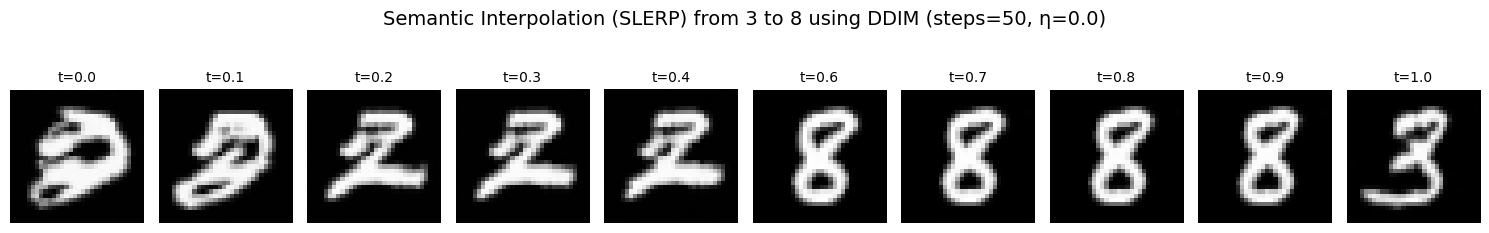

In [9]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for idx, img in enumerate(morphed_images):
    grid_img = torchvision.utils.make_grid(img, normalize=True, value_range=(-1, 1)).cpu().numpy().transpose((1, 2, 0))
    axes[idx].imshow(grid_img)
    axes[idx].axis('off')
    axes[idx].set_title(f"t={alphas[idx]:.1f}", fontsize=10)

plt.suptitle("Semantic Interpolation (SLERP) from 3 to 8 using DDIM (steps=50, η=0.0)", fontsize=14, y=1.15)
plt.tight_layout()
plt.savefig("outputs/ddim_interpolation.png", bbox_inches='tight')
plt.show()